# Chapter 3. The leaves, counted

**Week 1, Monday. Chapter 3 of 6: how many customers, and how often do they buy?**

**The need.** Marketing's Rs 12 crore buys customers. If the customers Kalpa already has never
come back, acquisition really is the only branch; if they do come back, frequency is a branch
Meera can grow without buying anyone new.

| | |
|---|---|
| The metric at stake | Customers, and orders per customer, orders over distinct customers in the window |
| Who asks | Meera, for the budget; the head of Retail-Plus and the marketing lead, who own the two branches |
| What a wrong number costs | "Nobody comes back" makes frequency look dead and Rs 12 crore look like the only way to grow |
| A real company with the same question | Reliance Retail reported 396 million registered customers at 30 June 2026 (Reliance Industries media release, 17 July 2026). A registered customer is a denominator of its own: divide a quarter's orders by it and you get a different, smaller metric than orders per customer who ordered. Which people you count is the whole question. |
| In the dossier (`study-notes/C2_W01_D01_domain_retail_STUDENT.md`) | Section 5, frequency and repeat rate: the window decides the answer, and every registered customer is a different denominator |

Chapter 2 built the tree and measured one branch: Rs 5,44,810 over 30 orders is an AOV of
Rs 18,160. This chapter fills the two customer branches and checks the tree multiplies back.

> **Kavya's review.** A customer is a person and an order is a row. Count people by their id,
> and say how you did it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix
revenue = sum(order["amount"] for order in ORDERS)
print(len(ORDERS), "orders,", kit.rupees(revenue), "booked")

30 orders, Rs 5,44,810 booked


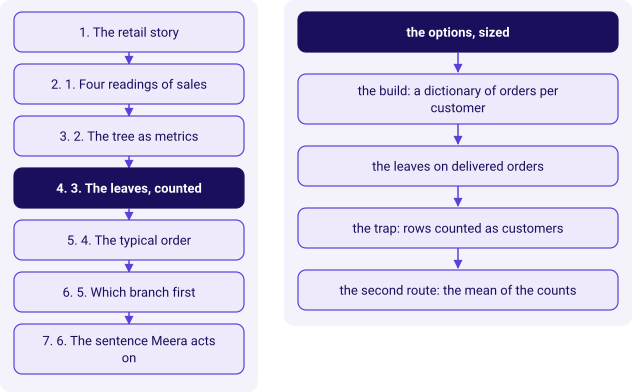

In [2]:
kit.side_by_side(
    kit.ladder(['The retail story', '1. Four readings of sales', '2. The tree as metrics', '3. The leaves, counted', '4. The typical order', '5. Which branch first', '6. The sentence Meera acts on'], lit=3, show=False),
    kit.vflow(['the options, sized', 'the build: a dictionary of orders per customer', 'the leaves on delivered orders', 'the trap: rows counted as customers', 'the second route: the mean of the counts'], lit=0, show=False),
)

## The options

Four ways to count customers, sized on 30 rows.

| Option | Passes over the rows | What it answers | Error on this file |
|---|---|---|---|
| A. `len(ORDERS)`, the row count | none | how many orders | counts a repeat customer once per order |
| B. `len(set(ids))`, distinct ids | one | how many customers | none; says nothing about who came back |
| C. A dictionary of orders per id | one | how many customers, how many orders each, who came back | none |
| D. Sort the ids and count where they change | a sort and a pass | how many customers | none if done right; easy to miscount by hand |

**The best-fit call.** C: one pass fills both customer branches and names the repeat buyers,
which is the number Meera's question turns on. B is the right call when only the count is
needed. **What would change it:** at millions of rows the same count is one
`COUNT(DISTINCT customer_id)` in the warehouse, which Week 2 teaches, and a loop in a notebook
stops being the tool.

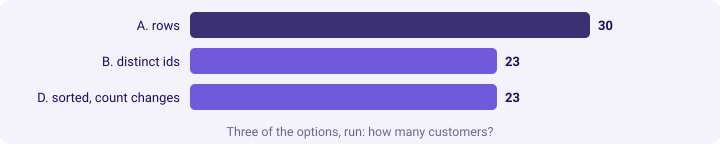

In [3]:
ids = [order["customer_id"] for order in ORDERS]
options = [("A. rows", len(ORDERS)), ("B. distinct ids", len(set(ids))),
           ("D. sorted, count changes", 1 + sum(1 for a, b in zip(sorted(ids), sorted(ids)[1:]) if a != b))]
kit.bars(options, lit=(0,), title="Three of the options, run: how many customers?")
kit.check("options B and D agree on distinct customers", options[1][1] == options[2][1], options[1][1])
kit.check("option A counts more customers than there are people", options[0][1] > options[1][1])

## 1. The build: a dictionary counts orders per customer

A set says how many customers there are and forgets the rest. A dictionary keeps a count per
id: the customer id is the key, the count of that customer's orders is the value.

**Predict before you run.** Of the 23 customers, how many bought more than once?

- a) None, because orders per customer is close to 1.
- b) 7, the difference between 30 orders and 23 customers.
- c) 16, the customers who are not new.
- d) 23, because the rate is above 1.

23 customers, 1.30 orders each; 16 bought once, 7 came back


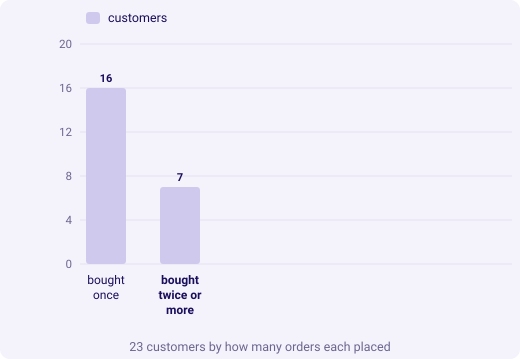

In [4]:
counts = {}
for order in ORDERS:
    cid = order["customer_id"]
    counts[cid] = counts.get(cid, 0) + 1
customers = len(counts)
per_customer = len(ORDERS) / customers
once = sum(1 for c in counts.values() if c == 1)
repeat = customers - once
print(f"{customers} customers, {per_customer:.2f} orders each; {once} bought once, {repeat} came back")
kit.columns(["bought once", "bought twice or more"], [("customers", [once, repeat])], lit=(1,),
            width=520, title="23 customers by how many orders each placed")

In [5]:
kit.check("orders per customer is 1.30 on distinct customers", round(per_customer, 2) == 1.30)
kit.check("16 bought once and 7 came back", (once, repeat) == (16, 7))
kit.check("the counts add back to 30 orders", sum(counts.values()) == 30)

**What happened.** The answer is b. Here the difference between orders and customers equals
the repeat buyers because nobody bought three times; a third order would part the two, which is
why the dictionary is the count to trust. One repeat customer carries Retail-Core on one order
and Retail-Plus on the other, since the segment is recorded on each order; a count of customers
per segment has to say which order's segment it used.

With every branch measured, the tree multiplies back:

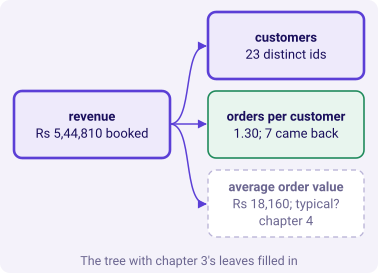

In [6]:
aov = revenue / len(ORDERS)
rebuilt = customers * per_customer * aov
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": f"{customers} distinct ids", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {repeat} came back", "kind": "good"},
    {"label": "average order value", "note": kit.rupees(aov) + "; typical? chapter 4", "kind": "unknown"}]},
    title="The tree with chapter 3's leaves filled in")
kit.check("customers x orders per customer x AOV = booked revenue", round(rebuilt) == revenue, kit.rupees(rebuilt))

## 2. The leaves move when the definition moves

Chapter 1 gave sales three readings, and every leaf inherits the choice. A customer whose only
order was cancelled drops out of customers.

**Predict before you run.** On the delivered definition, what happens to orders per customer?

- a) It stays at 1.30, since both sides shrink.
- b) It rises, because the loyal customers remain.
- c) It cannot be computed without the returns.
- d) It falls, because orders shrink faster than customers.

definition,orders,customers,orders per customer,came back,revenue
booked,30,23,1.30,7,"Rs 5,44,810"
not cancelled,26,21,1.24,5,"Rs 5,35,760"
delivered,21,19,1.11,2,"Rs 5,20,790"


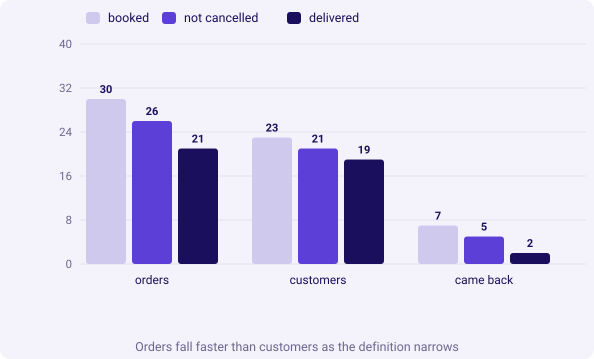

In [7]:
definitions = {"booked": {"delivered", "returned", "cancelled"},
               "not cancelled": {"delivered", "returned"}, "delivered": {"delivered"}}
leaves = {}
for name, keep in definitions.items():
    per = {}
    rupees = 0
    for order in ORDERS:
        if order["status"] in keep:
            per[order["customer_id"]] = per.get(order["customer_id"], 0) + 1
            rupees += order["amount"]
    n = sum(per.values())
    leaves[name] = {"orders": n, "customers": len(per), "per": n / len(per),
                    "came back": sum(1 for c in per.values() if c > 1), "revenue": rupees}
kit.table(["definition", "orders", "customers", "orders per customer", "came back", "revenue"],
          [(k, v["orders"], v["customers"], f'{v["per"]:.2f}', v["came back"], kit.rupees(v["revenue"]))
           for k, v in leaves.items()], caption="The leaves under each definition of sales")
kit.columns(["orders", "customers", "came back"],
            [(k, [leaves[k]["orders"], leaves[k]["customers"], leaves[k]["came back"]]) for k in leaves],
            title="Orders fall faster than customers as the definition narrows")
d = leaves["delivered"]
kit.check("delivered: 21 orders from 19 customers, 1.11 each",
          (d["orders"], d["customers"], round(d["per"], 2)) == (21, 19, 1.11))
kit.check("only 2 customers came back with both orders delivered", d["came back"] == 2)

**What happened.** The answer is d. Removing 9 cancelled and returned orders removes only 4
customers, and of the 7 who came back only 2 had both orders delivered. For Meera: customers
do return, and their second orders are the ones most often cancelled or sent back, so
frequency is a live branch that leaks.

## 3. The trap: every row counted as a customer

The first draft a colleague sent Meera counted this leaf in one line, from the row count.

**Predict before you run.** The hurried cell divides orders by the number of rows. What
orders-per-customer figure does it report?

- a) 1.30, the figure the tree needs.
- b) 0.77, because customers outnumber orders.
- c) 1.00, one order for every customer.
- d) 23.00, because the division runs the wrong way.

**The plausible wrong answer.**

Customers: 30
Orders per customer: 1.00, so nobody comes back


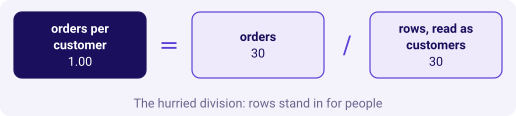

In [8]:
customers_hurried = len(ORDERS)
per_customer_hurried = len(ORDERS) / customers_hurried
print("Customers:", customers_hurried)
print(f"Orders per customer: {per_customer_hurried:.2f}, so nobody comes back")
kit.equation([f"orders per customer\n{per_customer_hurried:.2f}", "=", "orders\n30", "/",
              "rows, read as customers\n30"], title="The hurried division: rows stand in for people")

**Why it is wrong.** The answer is c. The division is correct and its denominator is wrong: a
row is an order, and one customer can place several. Reported to Meera, "1.00 orders per
customer, nobody comes back" says frequency is dead and the only way to grow is to buy
customers, which is marketing's case for Rs 12 crore made by a counting slip. The check compares
the ids in the list with the distinct ids.

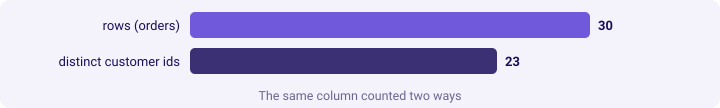

In [9]:
distinct = set(ids)
kit.bars([("rows (orders)", len(ids)), ("distinct customer ids", len(distinct))], lit=(1,),
         title="The same column counted two ways")
kit.check("the list holds one id per row", len(ids) == 30)
kit.check("the set holds 23 distinct customers", len(distinct) == 23, len(distinct))

**The fix, and what changed.** Divide by distinct customers, as the build did: 23, and 30 / 23
= 1.30 orders each. The draft's 1.00 goes nowhere, 7 customers are no longer invisible, and
"nobody comes back" is gone from the case for the Rs 12 crore.

## A second route: the mean of the counts

Orders per customer is also the mean of the dictionary's values: each customer's order count,
averaged over customers. It must equal orders over distinct customers.

In [10]:
second_route = sum(counts.values()) / len(counts)
kit.table(["route", "orders per customer"],
          [("len(ORDERS) / len(set(ids))", f"{len(ORDERS) / len(distinct):.4f}"),
           ("mean of the per-customer counts", f"{second_route:.4f}")],
          caption="Two routes to one rate")
kit.check("the two routes agree", abs(second_route - len(ORDERS) / len(distinct)) < 1e-12)
kit.check("the dictionary's keys are the set's members", set(counts) == distinct)

route,orders per customer
len(ORDERS) / len(set(ids)),1.3043
mean of the per-customer counts,1.3043


**When to switch.** The ratio route needs only two counts, which is what a report holds; the
counts route needs the rows and also gives the spread, 16 customers at one and 7 at two, which
the ratio hides. Use the counts whenever someone will ask "how many came back".

> **Kavya's review.** The division was fine; the denominator was a guess. Every rate you send upstairs carries the name
> of its denominator, and a count of people comes from their ids.

### In the interview

**[F] Your extract shows 30 orders and 30 customers; what do you check before saying nobody
comes back?** "Whether 30 customers means 30 distinct ids or 30 rows. I compare the length of
the id column with the length of its set; on Kalpa's quarter that is 30 against 23, so seven
orders came from people who had already bought. I would also check the window, since a
customer who buys every four months looks one-time in one quarter, and whether one person can
carry two ids."

**[SV] A list against a dictionary: when do you reach for each?** "A list when order matters or
I will walk every item. A dictionary when I look things up or count by a key, such as orders per
customer id. Real records are both: a list of dictionaries, one per row, which is what a JSON
array from an API looks like. Checking membership in a list walks every item, while a dictionary
goes straight to its key."

**[SV] How do you count distinct customers in Python, and why does a set give the answer a list
does not?** "`len(set(ids))`, because a set keeps each value once however often it is added,
while a list keeps every occurrence. When I also need orders per customer, a dictionary keyed by
id gives both."

### Depth: sets answer overlap questions

`&` keeps the ids two sets share and `|` the ids in either. The cell asks how many customers
used more than one channel.

In [11]:
by_channel = {"app": set(), "web": set(), "store": set()}
for order in ORDERS:
    by_channel[order["channel"]].add(order["customer_id"])
multi = sum(1 for cid in distinct if sum(cid in s for s in by_channel.values()) > 1)
kit.table(["question", "set expression", "answer"],
          [("customers on the app", "len(app)", len(by_channel["app"])),
           ("customers on both app and web", "len(app & web)", len(by_channel["app"] & by_channel["web"])),
           ("customers on any channel", "len(app | web | store)", len(by_channel["app"] | by_channel["web"] | by_channel["store"])),
           ("customers on more than one channel", "counted", multi)],
          caption="Set questions on the same 30 orders")
kit.check("the union of the channels is all 23 customers",
          len(by_channel["app"] | by_channel["web"] | by_channel["store"]) == 23)

question,set expression,answer
customers on the app,len(app),10
customers on both app and web,len(app & web),3
customers on any channel,len(app | web | store),23
customers on more than one channel,counted,7


All 7 repeat buyers came back through a different channel from their first. Seven customers
are too few to call that a pattern; it does say a frequency plan built on one channel would miss
how these customers return.

## What this chapter established

In [12]:
kit.table(["What we now know", "The evidence"],
          [("A row is an order; customers are counted by id", "30 rows, 23 customers"),
           ("Frequency is a live branch", "1.30 orders each; 7 of 23 came back"),
           ("The tree multiplies back", "23 x 1.30 x Rs 18,160 = Rs 5,44,810"),
           ("The definition moves every leaf", "delivered: 21 orders, 19 customers, 1.11")],
          caption="Chapter 3: the leaves, counted")
kit.check_summary()
print("Next: chapter 4 asks whether Rs 18,160 describes a typical Kalpa order.")

What we now know,The evidence
A row is an order; customers are counted by id,"30 rows, 23 customers"
Frequency is a live branch,1.30 orders each; 7 of 23 came back
The tree multiplies back,"23 x 1.30 x Rs 18,160 = Rs 5,44,810"
The definition moves every leaf,"delivered: 21 orders, 19 customers, 1.11"


Next: chapter 4 asks whether Rs 18,160 describes a typical Kalpa order.
